# Flood Detection Pipeline

## Objective

Detect flooded regions from Sentinel-1 SAR imagery using the GeoSAR library.

---

## Processing Workflow

Pre Flood Image
        ↓
Radiometric Conversion
        ↓
Speckle Filtering
        ↓
Change Detection
        ↓
Thresholding
        ↓
Flood Mask

---

## Current GeoSAR Modules

✔ SARImage

✔ Statistics

✔ Filters
    - Lee
    - Adaptive Lee
    - Frost

✔ Change Detection
    - Ratio
    - Log Ratio
    - Difference

✔ Flood Detection
    - Threshold

In [1]:
# ==========================================================
# Configuration
# ==========================================================

# ---------- Data ----------

PRE_IMAGE = "/home/ubuntu/notebooks/geospatial/sample_image_preflood1.tif"

POST_IMAGE = "/home/ubuntu/notebooks/geospatial/sample_image_postflood1.tif"

# ---------- Filter ----------

FILTER = "Frost"

WINDOW_SIZE = 5

# ---------- Change Detection ----------

CHANGE_METHOD = "Ratio"

# ---------- Flood Detection ----------

THRESHOLD = 0.35

THRESHOLD_DIRECTION = "less"

# ---------- Visualization ----------

FIGSIZE = (8,8)

HIST_BINS = 100

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.expanduser("~/notebooks/geospatial/"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
if module_path not in sys.path:
    print("$$$$$$$$")
    sys.path.append(module_path)
    # print(f"Sys path is {sys.path}")
#sys.path.append(os.path.abspath(".."))
import numpy as np
from sar.sar_metadata import AcquisitionMetadata
from sar.sar_io import load_sar
from sar.sar_collection import SARCollection
from sar.sar_filters import lee_filter,_extract_window
from sar.sar_statistics import equivalent_number_of_looks
from sar.sar_statistics import coefficient_of_variation,local_mean
from sar.sar_radiometry import db_to_linear
from sar.sar_statistics import local_noise_variance
import matplotlib.pyplot as plt
from sar.sar_statistics import local_variance
from sar.sar_filters import _lee_weight,_estimate_noise_variance,frost_filter,_validate_filter_inputs,_pad_image
from sar.sar_geometry import _distance_matrix
from sar.sar_filters import _frost_weights
from sar.sar_statistics import _weighted_window_mean
from sar.sar_radiometry import linear_to_db
from sar.sar_geometry import _create_result
from sar.sar_change import *
from sar.sar_flood import *
from sar.sar_operations import copy_image,create_empty_like,align_to_reference,difference

import numpy as np
import matplotlib.pyplot as plt
from sar.sar_threshold import _validate_threshold_image,_compute_histogram,otsu_threshold


from sar.sar_radiometry import db_to_linear

from sar.sar_filters import (
    lee_filter,
    frost_filter,
)

from sar.sar_change import (
    ratio_change,
    log_ratio_change,
    difference_change,
)

from sar.sar_flood import (
    threshold_flood,
)

$$$$$$$$


ModuleNotFoundError: No module named 'sar.sar_conversion'

In [3]:
def show_sar(
    image,
    title,
    cmap="gray",
    percentile=(2,98),
):
    """
    Display a SAR image with automatic
    percentile contrast stretching.
    """

    data = image.data

    valid = data[np.isfinite(data)]

    vmin = np.percentile(
        valid,
        percentile[0]
    )

    vmax = np.percentile(
        valid,
        percentile[1]
    )

    plt.figure(figsize=FIGSIZE)

    plt.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    plt.title(title)

    plt.colorbar()

    plt.axis("off")

    plt.show()

In [4]:
def show_histogram(
    image,
    title,
):
    """
    Display histogram of valid pixels.
    """

    values = image.data[
        np.isfinite(image.data)
    ]

    plt.figure(figsize=(7,4))

    plt.hist(
        values,
        bins=HIST_BINS,
    )

    plt.title(title)

    plt.xlabel("Pixel Value")

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

In [5]:
pre = load_sar(PRE_IMAGE)

post = load_sar(POST_IMAGE)

In [ ]:
pre.metadata.provenance

In [ ]:
print("=" * 60)
print("Pre-flood Image")
print("=" * 60)

print(pre)

print()

print("=" * 60)
print("Post-flood Image")
print("=" * 60)

print(post)

In [ ]:
print("=" * 60)
print("Pre Statistics")
print("=" * 60)

print(pre.statistics())

print()

print("=" * 60)
print("Post Statistics")
print("=" * 60)

print(post.statistics())

In [6]:
empty = create_empty_like(pre)

aligned_post = align_to_reference(pre,post)

In [ ]:
print("Shape Match      :", pre.data.shape == aligned_post.data.shape)

print("CRS Match        :", pre.crs == aligned_post.crs)

print("Transform Match  :", pre.transform == aligned_post.transform)

print("Value Scale      :", pre.value_scale, "/", aligned_post.value_scale)

In [ ]:
show_sar(
    pre,
    "Pre-flood SAR Image",
)

show_sar(
    aligned_post,
    "Post-flood SAR Image",
)

In [ ]:
show_histogram(
    pre,
    "Pre-flood Histogram",
)

show_histogram(
    aligned_post,
    "Post-flood Histogram",
)

In [7]:
# ==========================================
# Convert to Linear Scale
# ==========================================

pre_linear = db_to_linear(pre)

post_linear = db_to_linear(aligned_post)

In [ ]:
print("="*60)
print("Pre (Linear)")
print("="*60)
print(pre_linear.statistics())

print()

print("="*60)
print("Post (Linear)")
print("="*60)
print(post_linear.statistics())

In [ ]:
show_sar(
    pre_linear,
    "Pre Flood (Linear)"
)

show_sar(
    post_linear,
    "Post Flood (Linear)"
)

In [ ]:
if FILTER.lower() == "lee":

    pre_filtered = lee_filter(
        pre_linear,
        window_size=WINDOW_SIZE,
    )

    post_filtered = lee_filter(
        post_linear,
        window_size=WINDOW_SIZE,
    )

elif FILTER.lower() == "frost":

    pre_filtered = frost_filter(
        pre_linear,
        window_size=WINDOW_SIZE,
    )

    post_filtered = frost_filter(
        post_linear,
        window_size=WINDOW_SIZE,
    )

else:

    raise ValueError(
        f"Unknown filter: {FILTER}"
    )

In [ ]:
# ==========================================
# Change Detection
# ==========================================

ratio = ratio_change(
    pre_filtered,
    post_filtered,
)

log_ratio = log_ratio_change(
    pre_filtered,
    post_filtered,
)

difference = difference_change(
    pre_filtered,
    post_filtered,
)

In [ ]:
threshold = otsu_threshold(log_ratio)
print(threshold)

In [ ]:
flood = threshold_flood(
    log_ratio,
    threshold=threshold,
    direction="less",
)

In [ ]:
from sar.sar_postprocess import binary_closing
toy = _create_result(
    reference=flood,
    data=np.array([
        [0,0,0,0,0,0,0],
        [0,1,1,1,1,1,0],
        [0,1,1,0,1,1,0],
        [0,1,1,1,1,1,0],
        [0,0,0,0,0,0,0],
    ], dtype=float),
    mask=np.ones((5,7), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

expected = np.array([
    [0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,0,0,0,0,0,0],
], dtype=np.uint8)

assert np.array_equal(
    closed.data,
    expected,
)

print("✓ Passed")

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.array([
        [0,0,0,0,0],
        [0,1,1,1,0],
        [0,1,1,1,0],
        [0,1,1,1,0],
        [0,0,0,0,0],
    ], dtype=float),
    mask=np.ones((5,5), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

assert isinstance(closed, SARImage)

assert closed.data.shape == toy.data.shape

assert closed.mask.shape == toy.mask.shape

assert np.array_equal(
    closed.mask,
    toy.mask,
)

print("✓ Test A Passed")

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.array([
        [0,0,0,0,0,0,0],
        [0,1,1,1,1,1,0],
        [0,1,1,0,1,1,0],
        [0,1,1,1,1,1,0],
        [0,0,0,0,0,0,0],
    ], dtype=float),
    mask=np.ones((5,7), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

expected = np.array([
    [0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,0,0,0,0,0,0],
], dtype=np.uint8)

print("Result")
print(closed.data)

print("Expected")
print(expected)

assert np.array_equal(
    closed.data,
    expected,
)

print("✓ Test B Passed")

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.array([
        [0,0,0,0,0],
        [0,1,1,1,0],
        [0,1,1,1,0],
        [0,1,1,1,0],
        [0,0,0,0,0],
    ], dtype=float),
    mask=np.ones((5,5), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

expected = toy.data.astype(np.uint8)

print(closed.data)

assert np.array_equal(
    closed.data,
    expected,
)

print("✓ Test C Passed")

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.zeros((5,5), dtype=float),
    mask=np.ones((5,5), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

expected = np.zeros((5,5), dtype=np.uint8)

print(closed.data)

assert np.array_equal(
    closed.data,
    expected,
)

print("✓ Test D Passed")

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.ones((3,3), dtype=float),
    mask=np.ones((3,3), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

print(closed.data)

In [ ]:
toy.data

In [ ]:
closed.data

In [ ]:
expected

In [ ]:
import numpy as np
from scipy.ndimage import binary_closing

img = np.array([
    [0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0],
    [0,1,1,0,1,1,0],
    [0,1,1,1,1,1,0],
    [0,0,0,0,0,0,0],
], dtype=bool)

result = binary_closing(img)

print(result.astype(int))

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.array([
        [1,1,0,1,1]
    ], dtype=float),
    mask=np.ones((1,5), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

closed = binary_closing(toy)

expected = np.array([
    [1,1,1,1,1]
], dtype=np.uint8)

assert np.array_equal(
    closed.data,
    expected
)

print("✓ Test 2 Passed")

In [ ]:
############$$$$$$$$$$$$$$$$$$##############

In [ ]:
print("="*60)
print("Filtered Pre")
print("="*60)

print(pre_filtered.statistics())

print()

print("="*60)
print("Filtered Post")
print("="*60)

print(post_filtered.statistics())

In [ ]:
show_sar(
    pre_filtered,
    "Filtered Pre"
)

In [ ]:
show_sar(
    post_filtered,
    "Filtered Post"
)

In [ ]:
show_histogram(
    pre_linear,
    "Pre Linear"
)

show_histogram(
    pre_filtered,
    "Pre Filtered"
)

In [ ]:
print("="*60)
print("Filter Quality Assessment")
print("="*60)

pre_enl = equivalent_number_of_looks(pre_filtered)

post_enl = equivalent_number_of_looks(post_filtered)

show_sar(
    pre_enl,
    "Pre-filter ENL Map"
)

show_sar(
    post_enl,
    "Post-filter ENL Map"
)

In [ ]:
# ==========================================
# Change Detection
# ==========================================

ratio = ratio_change(
    pre_filtered,
    post_filtered,
)

log_ratio = log_ratio_change(
    pre_filtered,
    post_filtered,
)

difference = difference_change(
    pre_filtered,
    post_filtered,
)

In [ ]:
print("="*60)
print("Ratio")
print("="*60)
print(ratio.statistics())

print()

print("="*60)
print("Log Ratio")
print("="*60)
print(log_ratio.statistics())

print()

print("="*60)
print("Difference")
print("="*60)
print(difference.statistics())

In [ ]:
show_sar(
    ratio,
    "Ratio Change"
)

In [ ]:
show_sar(
    log_ratio,
    "Log Ratio Change"
)

In [ ]:
show_sar(
    difference,
    "Difference Change"
)

In [ ]:
show_histogram(
    ratio,
    "Ratio Histogram"
)

In [ ]:
show_histogram(
    log_ratio,
    "Log Ratio Histogram"
)

In [ ]:
show_histogram(
    difference,
    "Difference Histogram"
)

In [ ]:
# ==========================================
# Flood Detection
# ==========================================

flood = threshold_flood(
    ratio,
    threshold=THRESHOLD,
    direction=THRESHOLD_DIRECTION,
)

In [ ]:
show_sar(
    flood,
    "Flood Mask",
    cmap="Blues",
    percentile=(0,100),
)

In [ ]:
# Number of flooded pixels
flood_pixels = np.sum(flood.data == 1)

# Number of valid pixels
valid_pixels = np.sum(flood.mask)

# Percentage flooded
flood_percentage = (
    flood_pixels / valid_pixels
) * 100

print(f"Flood Pixels      : {flood_pixels:,}")
print(f"Valid Pixels      : {valid_pixels:,}")
print(f"Flood Percentage  : {flood_percentage:.2f}%")

In [ ]:
pixel_width = abs(flood.transform.a)
pixel_height = abs(flood.transform.e)

pixel_area = pixel_width * pixel_height

flood_area_km2 = (
    flood_pixels * pixel_area
) / 1_000_000

print(f"Flood Area : {flood_area_km2:.2f} km²")

In [ ]:
print(ratio.statistics())
print(log_ratio.statistics())
print(difference.statistics())

In [ ]:
values = ratio.data[
    ratio.mask
]

values = values[np.isfinite(values)]

In [ ]:
print(np.percentile(values,50))
print(np.percentile(values,90))
print(np.percentile(values,95))
print(np.percentile(values,99))
print(np.percentile(values,99.9))
print(np.percentile(values,99.99))

In [ ]:
hist, centers, edges = _compute_histogram(
    ratio
)

print(hist[:10])
print(centers[:10])

In [ ]:
threshold = otsu_threshold(
    ratio
)

print(threshold)

In [ ]:
mask = np.array([
    [True, True, False, False],
    [True, True, False, False]
])

In [ ]:
toy = _create_result(
    reference=pre_linear,
    data=np.array([
        [1,1,1,np.nan],
        [10,10,10,10]
    ], dtype=float),
    #mask=np.ones((2,4), dtype=bool),
    mask=mask,
    operation="toy",
    value_scale="Unitless",
)

t = otsu_threshold(
    toy,
    bins=16,
)

print(t)

In [ ]:
threshold = otsu_threshold(
    ratio
)

print(f"Otsu Threshold: {threshold:.4f}")

In [ ]:
hist, centers, edges = _compute_histogram(
    ratio,
    percentile_range=(0,99.9)
)

In [ ]:
toy = _create_result(
    reference=pre_linear,
    data=np.array([
        [1,2],
        [3,100]
    ], dtype=float),
    mask=np.ones((2,2), dtype=bool),
    operation="toy",
    value_scale="Unitless",
)

In [ ]:
hist, centers, edges = _compute_histogram(
    toy
)

In [ ]:
hist2, centers2, edges2 = _compute_histogram(
    toy,
    percentile_range=(0,75),
)

In [ ]:
hist, centers, _ = _compute_histogram(
    ratio,
    percentile_range=(0,99.9),
)

print(hist[:10])
print(centers[:10])

print("Histogram Sum:", hist.sum())

In [ ]:
hist, centers, _ = _compute_histogram(
    log_ratio,
    percentile_range=(0,99.9),
)

plt.figure(figsize=(8,4))

plt.plot(
    centers,
    hist,
)

plt.grid(True)

plt.xlabel("Ratio")

plt.ylabel("Frequency")

plt.title("Histogram Used by Otsu")

plt.show()

In [ ]:
threshold = otsu_threshold(log_ratio)

#print(threshold)

In [ ]:
flood = threshold_flood(
    log_ratio,
    threshold=threshold,
    direction="less",
)

In [ ]:
show_sar(
    flood,
    "Flood Mask",
    cmap="Blues",
    percentile=(0,100),
)

In [ ]:
# Number of flooded pixels
flood_pixels = np.sum(flood.data == 1)

# Number of valid pixels
valid_pixels = np.sum(flood.mask)

# Percentage flooded
flood_percentage = (
    flood_pixels / valid_pixels
) * 100

print(f"Flood Pixels      : {flood_pixels:,}")
print(f"Valid Pixels      : {valid_pixels:,}")
print(f"Flood Percentage  : {flood_percentage:.2f}%")

In [ ]:
############################

In [ ]:
import os
import sys
module_path = os.path.abspath(os.path.expanduser("~/notebooks/geospatial/"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
if module_path not in sys.path:
    print("$$$$$$$$")
    sys.path.append(module_path)
    # print(f"Sys path is {sys.path}")
#sys.path.append(os.path.abspath(".."))
import numpy as np
from sar.sar_metadata import AcquisitionMetadata
from sar.sar_io import load_sar
from sar.sar_collection import SARCollection
from sar.sar_filters import lee_filter,_extract_window
from sar.sar_statistics import equivalent_number_of_looks
from sar.sar_statistics import coefficient_of_variation,local_mean
from sar.sar_radiometry import db_to_linear
from sar.sar_statistics import local_noise_variance
import matplotlib.pyplot as plt
from sar.sar_statistics import local_variance
from sar.sar_filters import _lee_weight,_estimate_noise_variance,frost_filter,_validate_filter_inputs,_pad_image
from sar.sar_geometry import _distance_matrix
from sar.sar_filters import _frost_weights
from sar.sar_statistics import _weighted_window_mean
from sar.sar_radiometry import linear_to_db
from sar.sar_geometry import _create_result
from sar.sar_change import *
from sar.sar_flood import *
from sar.sar_operations import copy_image,create_empty_like,align_to_reference,difference
from sar_sar_threshold import *

#sys.path.append(os.path.abspath(".."))
# module_path = os.path.abspath(os.path.expanduser("~/notebooks"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
# if module_path not in sys.path:
#     print("$$$$$$$$")
#     sys.path.append(module_path)

FILTER = "Frost"

WINDOW_SIZE = 5

THRESHOLD = 0.35

POLARIZATION = "VV"

pre = load_sar("/home/ubuntu/notebooks/geospatial/sample_image_preflood1.tif")

post = load_sar("/home/ubuntu/notebooks/geospatial/sample_image_postflood1.tif")


collection = SARCollection()


pre_metadata = AcquisitionMetadata(
    platform="Sentinel-1A",
    sensor="SAR",
    acquisition_date="2022-05-01",
    polarization="VV",
    orbit_direction="DESCENDING",
    relative_orbit=77,
    beam_mode="IW",
    frequency_band="C",
)

pre = load_sar(
    "/home/ubuntu/notebooks/geospatial/sample_image_preflood1.tif",
    acquisition=pre_metadata,
)

post_metadata = AcquisitionMetadata(
    platform="Sentinel-1A",
    sensor="SAR",
    
    acquisition_date="2022-07-24",
    polarization="VV",
    orbit_direction="DESCENDING",
    relative_orbit=77,
    beam_mode="IW",
    frequency_band="C",
)

post = load_sar(
    "/home/ubuntu/notebooks/geospatial/sample_image_postflood1.tif",
    acquisition=post_metadata,
)

empty = create_empty_like(pre)

aligned_post = align_to_reference(
    pre,
    post
)
print("Pre and post aligned")
print(pre.statistics())
print()
print(aligned_post.statistics())

pre.plot()

post.plot()
      
pre_linear = db_to_linear(pre)
post_linear = db_to_linear(aligned_post)

print(pre_linear.statistics())
print()
print(post_linear.statistics())

if FILTER.lower() == "lee":

    pre_filtered = lee_filter(pre_linear)

    post_filtered = lee_filter(post_linear)

elif FILTER.lower() == "frost":

    pre_filtered = frost_filter(
        pre_linear,
        window_size=WINDOW_SIZE,
    )

    post_filtered = frost_filter(
        post_linear,
        window_size=WINDOW_SIZE,
    )

else:

    raise ValueError(
        "Unknown filter."
    )


ratio = ratio_change(
    pre_filtered,
    post_filtered,
)

print()
ratio.plot()
print()
print(ratio.statistics())
print()

flood = threshold_flood(
    ratio,
    threshold=THRESHOLD,
)

flood.plot()

flood_pixels = np.sum(
    flood.data == 1
)

valid_pixels = np.sum(
    flood.mask
)

percent = (
    flood_pixels
    /
    valid_pixels
    *
    100
)

print(f"Flood pixels : {flood_pixels:,}")

print(f"Flood %      : {percent:.2f}")

In [ ]:
flood.plot()

flood_pixels = np.sum(
    flood.data == 1
)

valid_pixels = np.sum(
    flood.mask
)

percent = (
    flood_pixels
    /
    valid_pixels
    *
    100
)

print(f"Flood pixels : {flood_pixels:,}")

print(f"Flood %      : {percent:.2f}")

pixel_area = 100

area_m2 = (
    flood_pixels
    *
    pixel_area
)

area_km2 = area_m2 / 1_000_000

print(area_km2)

In [ ]:
module_path = os.path.abspath(os.path.expanduser("~/notebooks"))

In [ ]:
print(os.path.abspath(".."))
print(sys.path)
print(module_path)

In [ ]:
from sar.sar_postprocess import _validate_binary_image,binary_opening
toy = _create_result(
    reference=pre_linear,
    data=np.array([
        [0,np.nan],
        [1,0]
    ]),
    mask=np.array([
        [True,False],
        [True,True]
    ]),
    operation="toy",
    value_scale="Binary",
)

_validate_binary_image(toy)


In [ ]:
# ==========================================
# Flood Detection
# ==========================================

flood = threshold_flood(
    ratio,
    threshold=THRESHOLD,
    direction=THRESHOLD_DIRECTION,
)

In [ ]:
binary_opening(
    flood,
    iterations=0,
)

In [ ]:
from sar.sar_postprocess import label_connected_components
toy = _create_result(
    reference=flood,
    data=np.array([
        [1,1,1],
        [1,1,1],
        [1,1,1]
    ], dtype=float),
    mask=np.ones((3,3), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

print(label_connected_components(toy))

#print(opened.data)
# opened = binary_opening(toy)

# print(opened.data)

In [ ]:
toy = _create_result(
    reference=flood,
    data=np.array([
        [1,1,1,0,0],
        [1,1,1,1,0],
        [1,1,1,0,0],
    ], dtype=float),
    mask=np.ones((3,5), dtype=bool),
    operation="toy",
    value_scale=flood.value_scale,
)

opened = binary_opening(toy)

print(opened.data)

In [ ]:
assert np.array_equal(
    opened.mask,
    toy.mask
)

In [ ]:
from sar.sar_postprocess import binary_opening
opened = binary_opening(
    flood,
)

In [ ]:
show_sar(
    flood,
    "Original Flood Mask",
    cmap="Blues",
    percentile=(0,100),
)

In [ ]:
show_sar(
    opened,
    "Binary Opening",
    cmap="Blues",
    percentile=(0,100),
)

In [ ]:
print("Original :", np.sum(flood.data))
print("Opened   :", np.sum(opened.data))

In [ ]:
labels, n = label_connected_components(
    opened,
)

print(n)

In [ ]:
plt.figure(figsize=(10,10))

plt.imshow(
    labels,
    cmap="nipy_spectral",
)

plt.colorbar()

plt.title(
    f"{n} Connected Components"
)

plt.show()

In [ ]:
labels, n = label_connected_components(opened)

In [ ]:
labels

In [ ]:
sizes = np.bincount(labels.ravel())
print(sizes[0])
# Ignore background
sizes = sizes[1:]

In [ ]:
sizes[1335]

In [ ]:
print("Largest :", sizes.max())
print("Median  :", np.median(sizes))
print("Mean    :", np.mean(sizes))

for p in [50, 75, 90, 95, 99]:
    print(
        p,
        np.percentile(sizes, p)
    )
    

In [ ]:
np.where(sizes == 246998)[0]

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    sizes,
    bins=100,
    log=True,
)

plt.xlabel("Component Size (pixels)")
plt.ylabel("Count (log)")
plt.title("Connected Component Size Distribution")

plt.grid(True)

plt.show()

In [ ]:
from sar.sar_postprocess import remove_small_objects
assert np.array_equal(
    result.mask,
    toy.mask
)

In [ ]:
clean10 = remove_small_objects(
    opened,
    min_size=10,
)

clean20 = remove_small_objects(
    opened,
    min_size=20,
)

clean50 = remove_small_objects(
    opened,
    min_size=50,
)

In [ ]:
print(np.sum(clean10.data))
print(np.sum(clean20.data))
print(np.sum(clean50.data))

In [ ]:
flood = threshold_flood(
    log_ratio,
    threshold=THRESHOLD,
    direction="less",
)

In [ ]:
original = flood

In [ ]:
opened = binary_opening(
    original
)

In [ ]:
opened_20 = remove_small_objects(
    opened,
    min_size=20,
)

In [ ]:
opened_50 = remove_small_objects(
    opened,
    min_size=50,
)

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)

images = [
    original,
    opened,
    opened_20,
    opened_50,
]

titles = [
    "Original Flood Mask",
    "Binary Opening",
    "Opening + Remove <20",
    "Opening + Remove <50",
]

for ax, image, title in zip(
    axes.ravel(),
    images,
    titles,
):
    ax.imshow(
        image.data,
        cmap="Blues",
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
print("Original :", int(np.sum(original.data)))
print("Opening  :", int(np.sum(opened.data)))
print("Open+20  :", int(np.sum(opened_20.data)))
print("Open+50  :", int(np.sum(opened_50.data)))

In [ ]:
baseline = np.sum(original.data)

for name, img in [
    ("Opening", opened),
    ("Open+20", opened_20),
    ("Open+50", opened_50),
]:
    removed = baseline - np.sum(img.data)

    print(
        f"{name:10s}"
        f" Removed: {removed:8.0f}"
        f" ({removed / baseline * 100:.2f}%)"
    )

In [ ]:
removed20 = original.data - opened_20.data

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    removed20,
    cmap="Reds",
)

plt.title("Pixels Removed (min_size=20)")
plt.axis("off")

plt.show()

In [ ]:
from sar.sar_pipeline import _ensure_linear
result = _ensure_linear(pre_linear)

assert result is pre_linear

print("✓ Test 1A Passed")

In [ ]:
linear = _ensure_linear(pre)

assert linear.value_scale == "Linear"

print("✓ Test 1B Passed")

In [ ]:
linear = _ensure_linear(post_linear)

assert linear.value_scale == "Linear"

print("✓ Test 1B Passed")

In [ ]:
toy = _create_result(
    reference=pre_linear,
    data=np.ones((3,3)),
    mask=np.ones((3,3), dtype=bool),
    operation="toy",
    value_scale="Kelvin",
)

try:

    _ensure_linear(toy)

    raise AssertionError

except ValueError:

    print("✓ Test 1C Passed")

In [ ]:
from sar.sar_pipeline import _apply_filter
filtered = _apply_filter(
    pre_linear,
    filter_name="frost",
)

assert isinstance(
    filtered,
    SARImage,
)

print("✓ Test 2A Passed")

In [ ]:
filtered = _apply_filter(
    pre_linear,
    filter_name="lee",
)

assert isinstance(
    filtered,
    SARImage,
)

print("✓ Test 2B Passed")

In [ ]:
try:

    _apply_filter(
        pre_linear,
        filter_name="median",
    )

    raise AssertionError

except ValueError:

    print("✓ Test 2C Passed")

In [ ]:
from sar.sar_pipeline import _compute_change
change = _compute_change(
    pre_linear,
    post_linear,
)

assert isinstance(
    change,
    SARImage,
)

print("✓ Test 3 Passed")

In [ ]:
from sar.sar_pipeline import _compute_threshold
threshold = _compute_threshold(
    log_ratio,
)

assert isinstance(
    threshold,
    float,
)

print("✓ Test 4 Passed")

In [ ]:
try:

    _compute_threshold(
        log_ratio,
        method="triangle",
    )

    raise AssertionError

except ValueError:

    print("✓ Test 4B Passed")

In [ ]:
flood = threshold_flood(
    log_ratio,
    threshold=threshold,
    direction="less",
)

In [ ]:
from sar.sar_pipeline import _postprocess
result = _postprocess(
    flood,
)

assert isinstance(
    result,
    SARImage,
)

assert result.data.shape == flood.data.shape

print("✓ Test 5 Passed")

Best index: 151
Threshold : -1.080517447638465


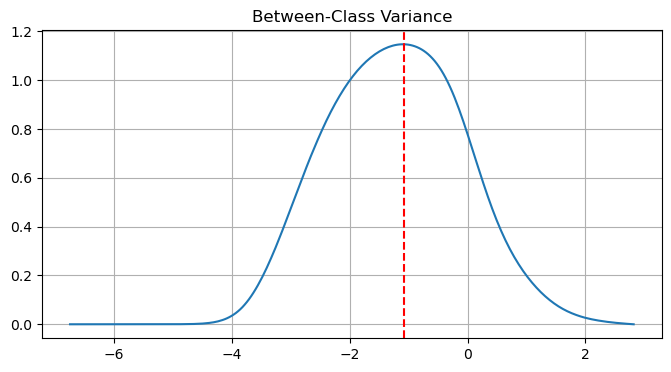

image.data dtype : uint8
image.data shape : (5608, 5071)
structure dtype  : bool
structure shape  : (3, 3)
iterations       : 1
bool


In [8]:
from sar.sar_pipeline import detect_flood
result = detect_flood(
    pre_linear,
    post_linear,
)

assert isinstance(result, SARImage)

In [9]:
assert isinstance(
    result,
    SARImage,
)

print("✓ Output is SARImage")

✓ Output is SARImage


In [10]:
assert result.data.shape == pre_linear.data.shape

print("✓ Shape preserved")

✓ Shape preserved


In [11]:
assert np.all(
    np.isin(
        result.data,
        [0,1]
    )
)

print("✓ Binary output")

✓ Binary output


In [12]:
assert np.array_equal(
    result.mask,
    pre_linear.mask
)

print("✓ Mask preserved")

AssertionError: 

In [13]:
print(result.statistics())

{'minimum': 0.0, 'maximum': 1.0, 'mean': 0.26581218305161153, 'std': 0.4417647183659513, 'valid_pixels': 15367644, 'nodata_pixels': 13070524}


In [14]:
print(
    "Flood Pixels:",
    int(result.data.sum())
)

Flood Pixels: 4084999


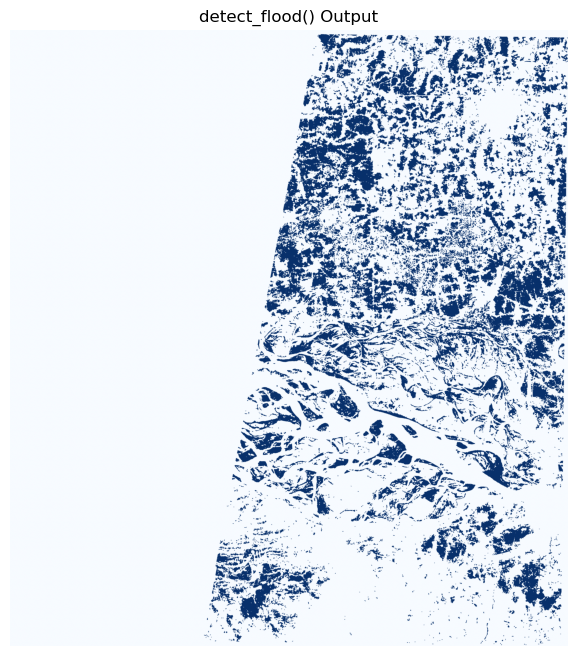

In [15]:
plt.figure(figsize=(8,8))

plt.imshow(
    result.data,
    cmap="Blues"
)

plt.title("detect_flood() Output")

plt.axis("off")

plt.show()

In [16]:
print(np.sum(pre_linear.mask))
print(np.sum(post_linear.mask))
print(np.sum(result.mask))
print(np.sum(pre_linear.mask != result.mask))

15380333
15378665
15367644
12689


In [ ]:
from sar.sar_pipeline import _ensure_linear,_apply_filter
pre = _ensure_linear(pre_linear)
post = _ensure_linear(post_linear)

print("Pre         :", np.sum(pre.mask))
print("Post        :", np.sum(post.mask))

pre_f = _apply_filter(pre, filter_name="frost")
post_f = _apply_filter(post, filter_name="frost")

print("Pre Filter  :", np.sum(pre_f.mask))
print("Post Filter :", np.sum(post_f.mask))

Change      : 15367644
Expected mask : 15367644
Change mask   : 15367644
Pixels removed by np.isfinite: 0
Best index: 151
Threshold : -1.080517447638465


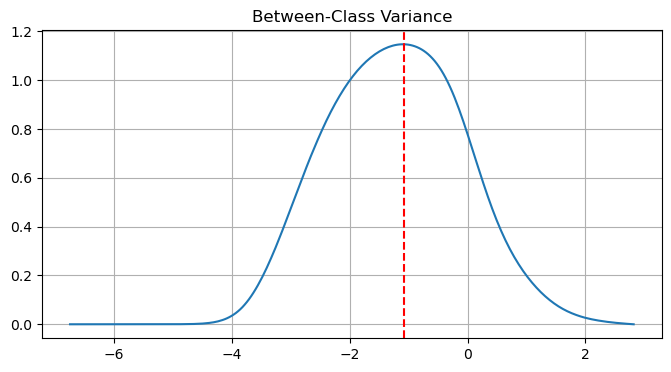

Threshold   : 15367644
Opening     : 15367644
image.data dtype : uint8
image.data shape : (5608, 5071)
structure dtype  : bool
structure shape  : (3, 3)
iterations       : 1
bool
Closing     : 15367644
Final       : 15367644


In [23]:
from sar.sar_pipeline import _compute_change,_compute_threshold
from sar.sar_postprocess import binary_opening,binary_closing,remove_small_objects
change = _compute_change(pre_f, post_f)
print("Change      :", np.sum(change.mask))
expected_mask = (
    pre_f.mask &
    post_f.mask
)

print("Expected mask :", np.sum(expected_mask))
print("Change mask   :", np.sum(change.mask))

print(
    "Pixels removed by np.isfinite:",
    np.sum(expected_mask & ~change.mask)
)
threshold = _compute_threshold(change)

flood = threshold_flood(
    change,
    threshold=threshold,
    direction="less",
)
print("Threshold   :", np.sum(flood.mask))

opened = binary_opening(flood)
print("Opening     :", np.sum(opened.mask))

closed = binary_closing(opened)
print("Closing     :", np.sum(closed.mask))

clean = remove_small_objects(closed)
print("Final       :", np.sum(clean.mask))

In [24]:
assert np.array_equal(
    result.mask,
    change.mask
)

print("✓ Mask preserved through pipeline")

✓ Mask preserved through pipeline


Best index: 151
Threshold : -1.080517447638465


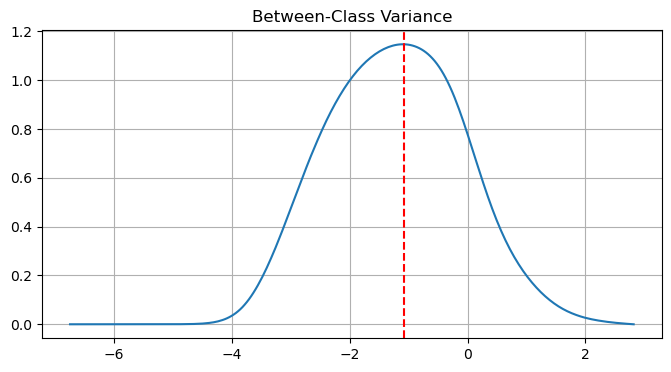

image.data dtype : uint8
image.data shape : (5608, 5071)
structure dtype  : bool
structure shape  : (3, 3)
iterations       : 1
bool


In [25]:
manual = clean

api = detect_flood(
    pre_linear,
    post_linear,
)

In [26]:
print("Manual :", int(manual.data.sum()))
print("API    :", int(api.data.sum()))

print(
    np.sum(manual.data != api.data)
)

Manual : 4084999
API    : 4084999
0


# GeoSAR

**GeoSAR** is an open-source Python library for Synthetic Aperture Radar (SAR) image processing, designed with an emphasis on modularity, reproducibility, and scientific transparency.

Version 1.0 implements a complete Sentinel-1 flood detection workflow, from radiometric conversion to a validated binary flood mask.

Rather than functioning as a black-box application, GeoSAR exposes every intermediate processing step, enabling researchers, students, and practitioners to inspect, validate, and extend the workflow.

GeoSAR is built around a simple philosophy:

> Build reusable SAR processing components that are scientifically correct, independently testable, and easy to combine into complete workflows.

## Why GeoSAR?

Most SAR processing software provides complete processing pipelines but exposes little of the underlying implementation.

GeoSAR takes a different approach.

Every algorithm is implemented as an independent, reusable component with a consistent API. This allows users to:

- understand each processing step
- validate intermediate results
- replace algorithms easily
- build custom workflows
- reproduce published experiments

The result is a library that is both practical and educational.

                    GeoSAR

                        │

        ┌───────────────┼────────────────┐

        ▼               ▼               ▼

   Image Model      Processing      Pipelines

        │               │               │

        ▼               ▼               ▼

    SARImage      Filters, Change   detect_flood()

                    Thresholding

                    Morphology


## Engineering Principles

GeoSAR follows a consistent engineering philosophy.

Every public function:

- validates its inputs
- preserves metadata
- preserves valid-data masks
- never modifies input objects
- returns a new `SARImage`
- includes NumPy-style documentation
- has unit tests
- has integration tests

These principles ensure that every module behaves consistently throughout the library.

## Validation

GeoSAR has been validated at three levels.

### Unit Testing

Each processing module has dedicated unit tests covering

- functional correctness
- input validation
- edge cases
- mask propagation

### Integration Testing

The complete processing pipeline has been validated against a manually implemented Sentinel-1 workflow.

## Vision

Version 1 establishes the core architecture for SAR image processing.

Future versions will extend GeoSAR into a general-purpose framework supporting

- flood monitoring
- agriculture
- forestry
- land cover analysis
- disaster management
- multi-temporal SAR analysis
- polarimetric SAR

## Philosophy

GeoSAR was developed from first principles.

Every algorithm was implemented, tested, profiled, validated, and integrated before moving to the next component.

This incremental engineering approach has produced a modular and highly testable SAR processing library that can continue to grow without sacrificing code quality.

In [4]:
import sar

print(sar.__version__)

sar.about()

1.0.0
GeoSAR Version : 1.0.0
Synthetic Aperture Radar Processing Library
Author         : Santosh Kumar Singh
License        : MIT


In [5]:
from sar import *

print(SARImage)
print(detect_flood)
print(frost_filter)
print(otsu_threshold)

<class 'sar.sar_image.SARImage'>
<function detect_flood at 0x7f57ddd90940>
<function frost_filter at 0x7f57dee00ca0>
<function otsu_threshold at 0x7f57ddd90160>
